# RFDiffusion — Backbone Generation

Visualization notebook: training curves, SE(3) noising, reverse diffusion trajectory, generated backbones, bond statistics.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(Path(".").resolve()))

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
from model import RFDiffusion, SE3Diffusion, RigidTransform, sample, compute_local_frame
from train import parse_pdb

model = RFDiffusion().to(device)
ckpt = torch.load("checkpoint.pt", map_location=device, weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"RFDiffusion loaded: {model.count_parameters():,} parameters")

pdb = parse_pdb(Path("../data/pdb/1CRN.pdb"))
true_CA = pdb["coords_CA"]
true_N = pdb["coords_N"]
true_C = pdb["coords_C"]
L_crn = true_CA.shape[0]
print(f"1CRN: {L_crn} residues")

RFDiffusion loaded: 10,299,894 parameters
1CRN: 46 residues


## 1. Training Curves

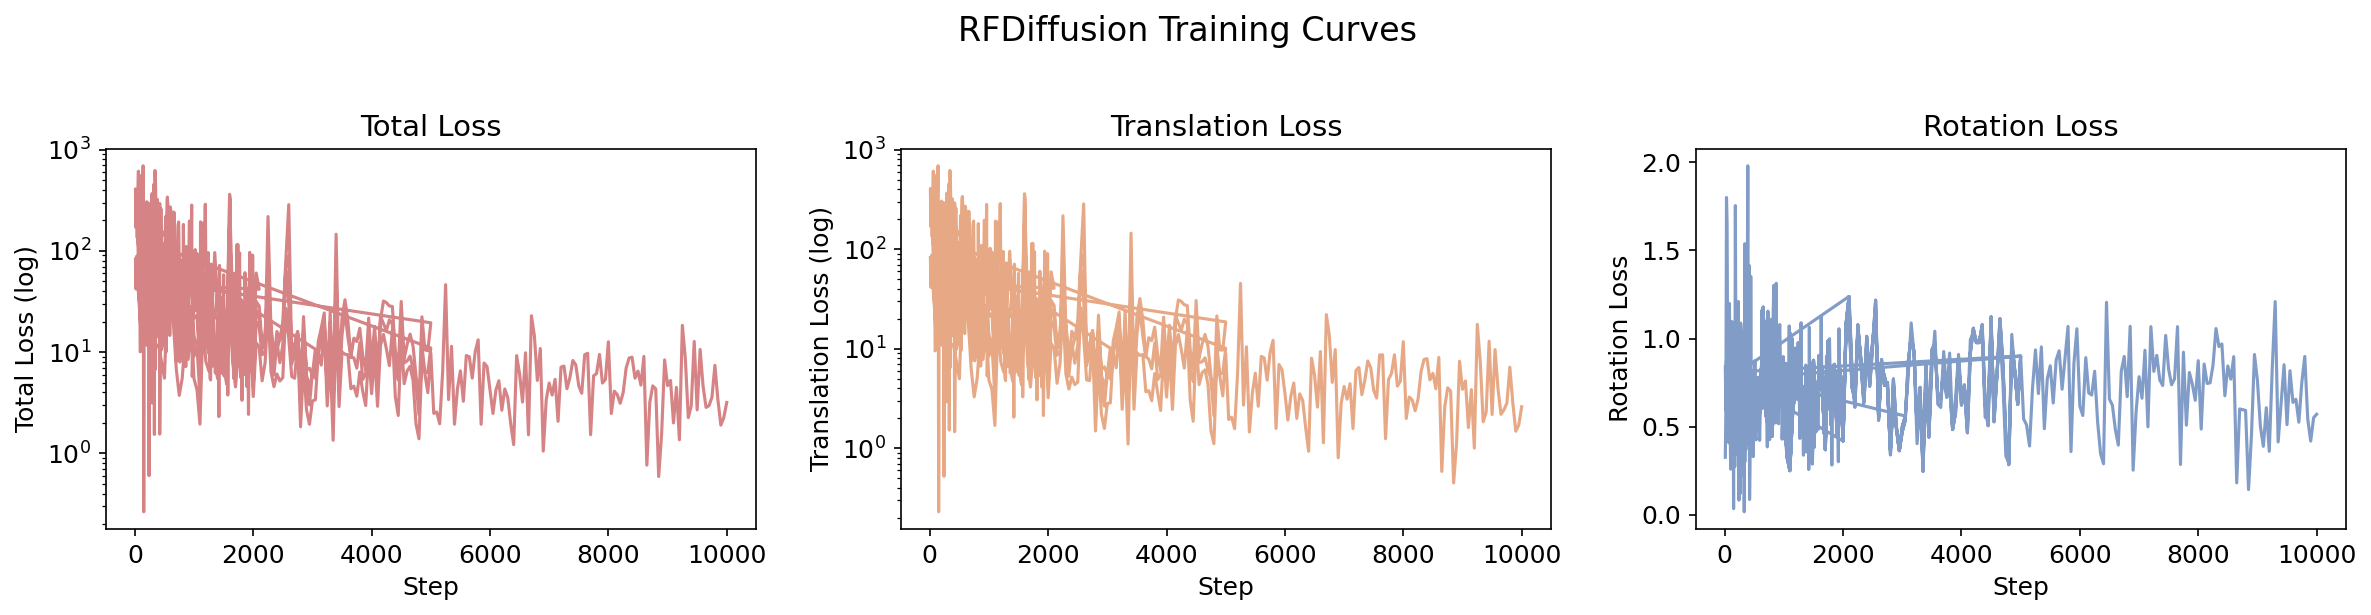

In [3]:
def parse_log(log_path, fields):
    """Parse training log. Returns dict of field_name -> list of floats."""
    data = {f: [] for f in fields}
    pattern = {f: re.compile(rf"{f}=([0-9eE.+-]+)") for f in fields}
    with open(log_path) as fh:
        for line in fh:
            if "step=" not in line:
                continue
            for f in fields:
                m = pattern[f].search(line)
                if m:
                    data[f].append(float(m.group(1)))
    return {f: np.array(v) for f, v in data.items()}


log = parse_log("../outputs/rfdiffusion/train.log", ["step", "loss", "trans", "rot"])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].semilogy(log["step"], log["loss"], color="#C44E52", alpha=0.7)
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Total Loss (log)")
axes[0].set_title("Total Loss")

axes[1].semilogy(log["step"], log["trans"], color="#DD8452", alpha=0.7)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Translation Loss (log)")
axes[1].set_title("Translation Loss")

axes[2].plot(log["step"], log["rot"], color="#4C72B0", alpha=0.7)
axes[2].set_xlabel("Step")
axes[2].set_ylabel("Rotation Loss")
axes[2].set_title("Rotation Loss")

fig.suptitle("RFDiffusion Training Curves", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## 2. SE(3) Noising Process

Progressive corruption of a real backbone via forward diffusion.

/tmp/ipykernel_2867141/1211930242.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


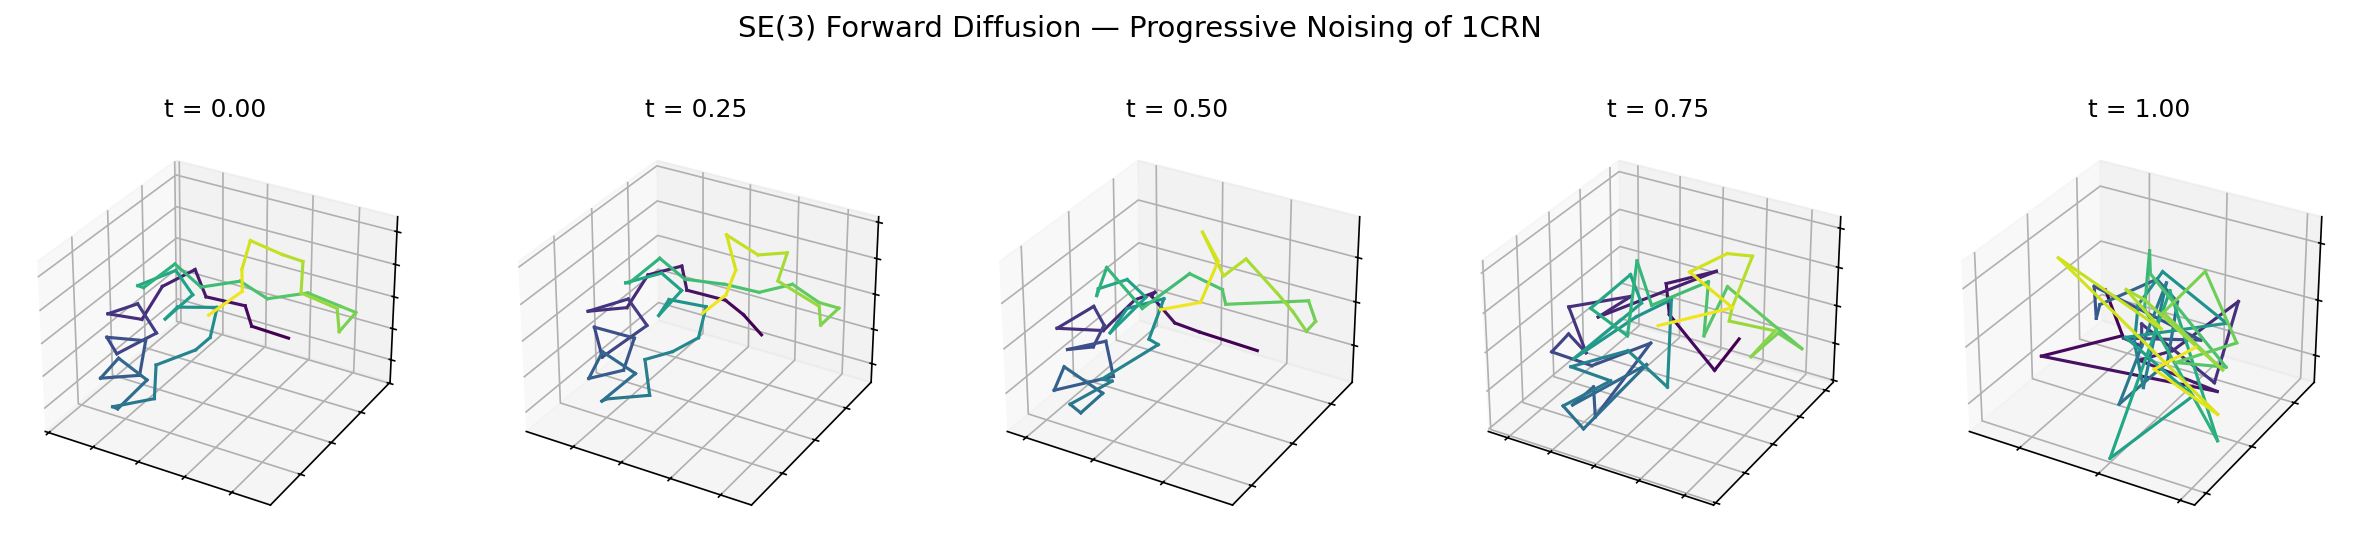

In [4]:
# Build frames from real backbone
frames_0 = compute_local_frame(true_N, true_CA, true_C)  # [L]
diffusion = SE3Diffusion()

t_values = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={"projection": "3d"})

for ax, t in zip(axes, t_values):
    if t == 0.0:
        ca = true_CA.numpy()
    else:
        t_tensor = torch.full((L_crn,), t)
        noisy_frames, _ = diffusion.forward_marginal(frames_0, t_tensor)
        ca = noisy_frames.trans.detach().numpy()  # CA = translation
    ca_c = ca - ca.mean(axis=0)
    colors = plt.cm.viridis(np.linspace(0, 1, L_crn))
    for i in range(L_crn - 1):
        ax.plot(ca_c[i:i+2, 0], ca_c[i:i+2, 1], ca_c[i:i+2, 2],
                color=colors[i], linewidth=1.5)
    ax.set_title(f"t = {t:.2f}", fontsize=12)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

fig.suptitle("SE(3) Forward Diffusion — Progressive Noising of 1CRN", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 3. Reverse Diffusion Trajectory

Generate a backbone via reverse diffusion and show snapshots.

In [5]:
torch.manual_seed(42)
trajectory = sample(model.network, diffusion, num_residues=50, num_steps=100, device=device)
print(f"Generated trajectory: {len(trajectory)} frames, {trajectory[-1].trans.shape[0]} residues")

Generated trajectory: 101 frames, 50 residues


/tmp/ipykernel_2867141/3348857781.py:20: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


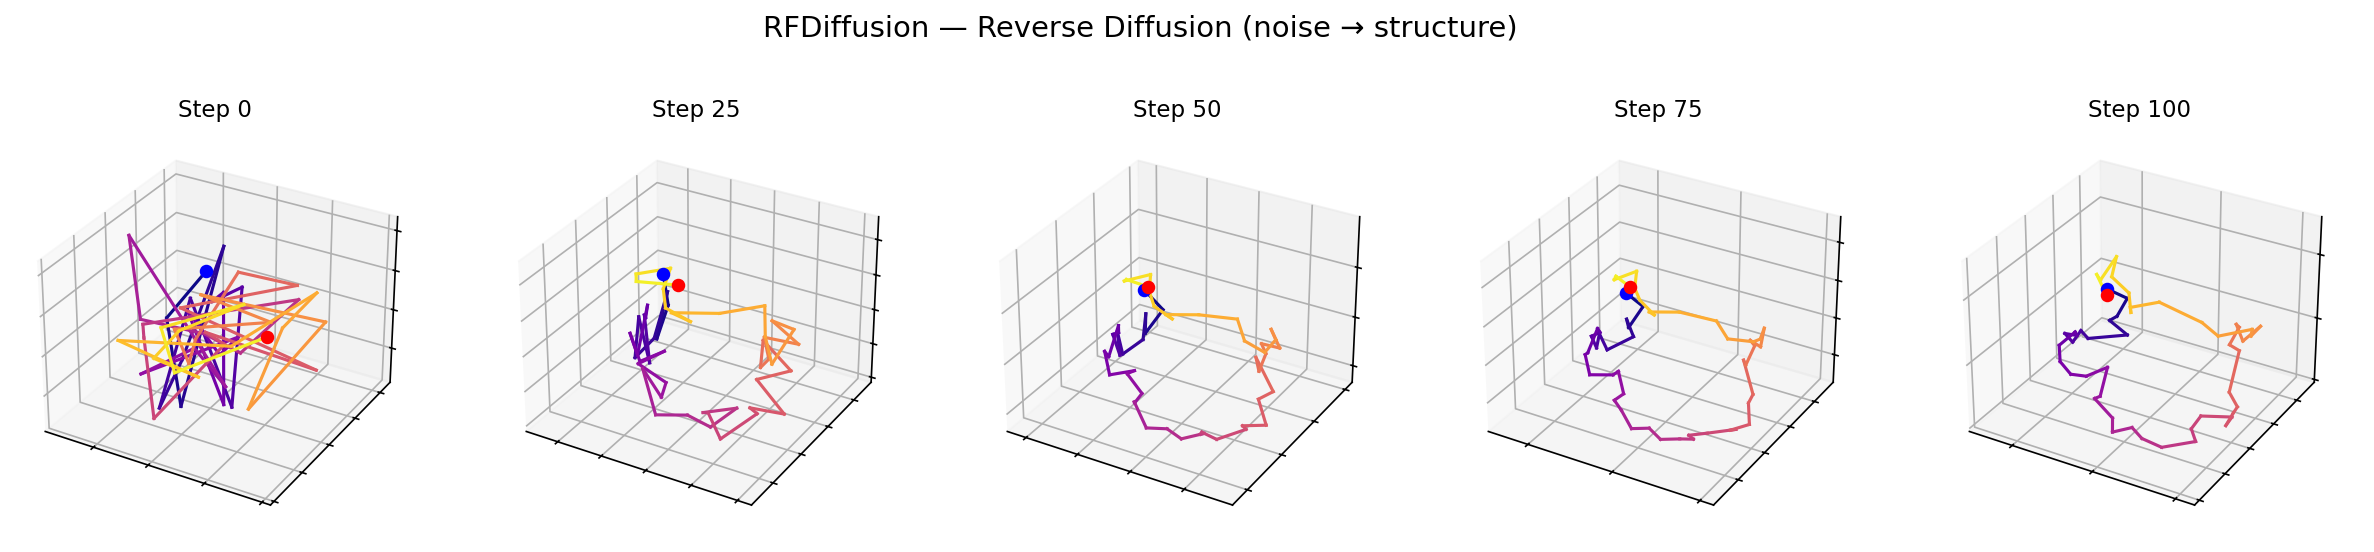

In [6]:
step_indices = [0, 25, 50, 75, 100]

fig, axes = plt.subplots(1, 5, figsize=(20, 4), subplot_kw={"projection": "3d"})
for ax, si in zip(axes, step_indices):
    ca = trajectory[si].trans.cpu().numpy()  # [L, 3]
    ca_c = ca - ca.mean(axis=0)
    L_gen = len(ca_c)
    colors = plt.cm.plasma(np.linspace(0, 1, L_gen))
    for i in range(L_gen - 1):
        ax.plot(ca_c[i:i+2, 0], ca_c[i:i+2, 1], ca_c[i:i+2, 2],
                color=colors[i], linewidth=1.5)
    ax.scatter(*ca_c[0], color="blue", s=30, zorder=5)
    ax.scatter(*ca_c[-1], color="red", s=30, zorder=5)
    ax.set_title(f"Step {si}", fontsize=11)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])

fig.suptitle("RFDiffusion — Reverse Diffusion (noise \u2192 structure)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 4. Generated Backbones

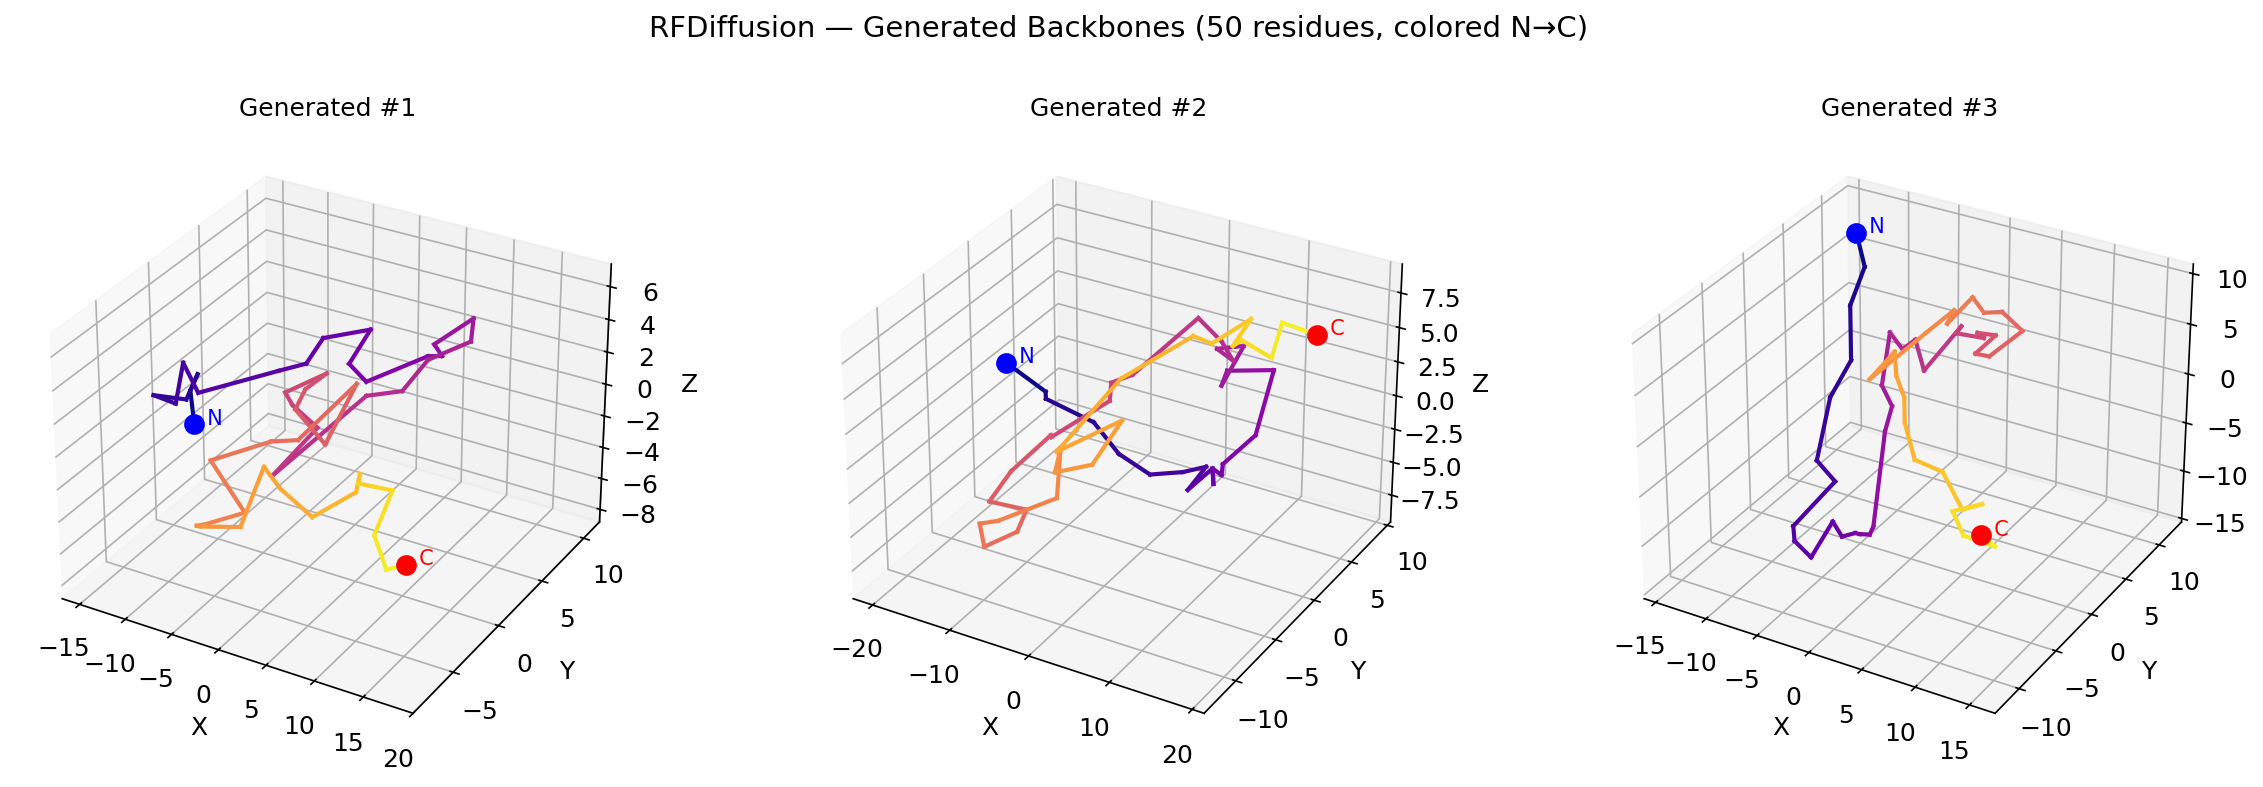

In [7]:
# Generate 3 backbones with different seeds
generated = []
for seed in [0, 1, 2]:
    torch.manual_seed(seed)
    traj = sample(model.network, diffusion, num_residues=50, num_steps=100, device=device)
    generated.append(traj[-1].trans.cpu().numpy())

fig, axes = plt.subplots(1, 3, figsize=(16, 5), subplot_kw={"projection": "3d"})
for ax, (ca, seed) in zip(axes, zip(generated, [0, 1, 2])):
    ca_c = ca - ca.mean(axis=0)
    L_gen = len(ca_c)
    colors = plt.cm.plasma(np.linspace(0, 1, L_gen))
    for i in range(L_gen - 1):
        ax.plot(ca_c[i:i+2, 0], ca_c[i:i+2, 1], ca_c[i:i+2, 2],
                color=colors[i], linewidth=2)
    ax.scatter(*ca_c[0], color="blue", s=80, zorder=5)
    ax.scatter(*ca_c[-1], color="red", s=80, zorder=5)
    ax.text(*ca_c[0], "  N", fontsize=10, color="blue")
    ax.text(*ca_c[-1], "  C", fontsize=10, color="red")
    ax.set_title(f"Generated #{seed + 1}", fontsize=12)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

fig.suptitle("RFDiffusion — Generated Backbones (50 residues, colored N\u2192C)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 5. Bond Statistics

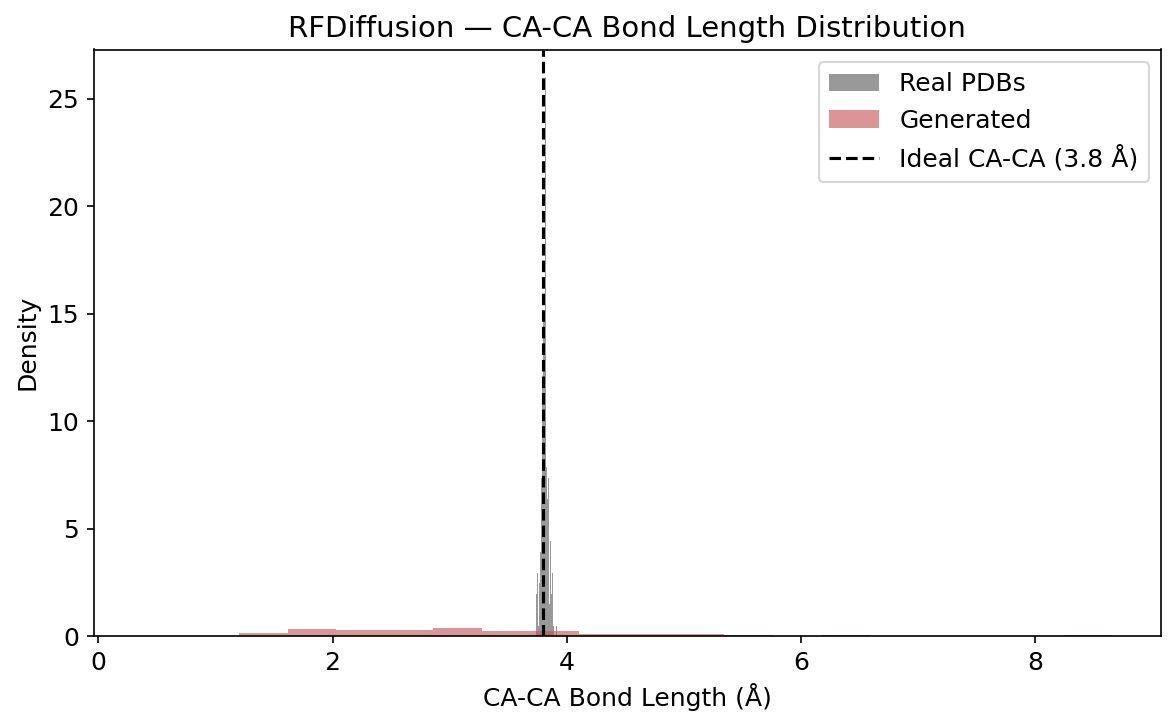

Generated: mean=3.30 Å, std=1.46 Å
Real:      mean=3.81 Å, std=0.03 Å


In [8]:
# CA-CA bond lengths: generated vs real
gen_bonds = []
for ca in generated:
    bonds = np.linalg.norm(np.diff(ca, axis=0), axis=1)
    gen_bonds.append(bonds)
gen_bonds = np.concatenate(gen_bonds)

# Real bond lengths from training PDBs
real_bonds = []
for pdb_file in sorted(Path("../data/pdb").glob("*.pdb")):
    pdb_data = parse_pdb(pdb_file)
    if pdb_data is not None:
        ca_coords = pdb_data["coords_CA"].numpy()
        bonds = np.linalg.norm(np.diff(ca_coords, axis=0), axis=1)
        real_bonds.append(bonds)
real_bonds = np.concatenate(real_bonds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(real_bonds, bins=40, alpha=0.6, color="#555555", label="Real PDBs", density=True)
ax.hist(gen_bonds, bins=20, alpha=0.6, color="#C44E52", label="Generated", density=True)
ax.axvline(x=3.8, color="black", linestyle="--", linewidth=1.5, label="Ideal CA-CA (3.8 \u00c5)")
ax.set_xlabel("CA-CA Bond Length (\u00c5)")
ax.set_ylabel("Density")
ax.set_title("RFDiffusion — CA-CA Bond Length Distribution")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Generated: mean={gen_bonds.mean():.2f} \u00c5, std={gen_bonds.std():.2f} \u00c5")
print(f"Real:      mean={real_bonds.mean():.2f} \u00c5, std={real_bonds.std():.2f} \u00c5")